<a href="https://colab.research.google.com/github/MonaKhadija/Data-Analytics-and-Artificial-Intelligence-Project-DAAI/blob/main/Project1_Khadija_Bassiouni.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project 1: Data Collection and Initial Analysis of Stock Market Data**

Student name: Khadija bassiouni

Setting up the environment and understanding the dataset:

NB: since the dataset is large, and in order to prevent the notebook from crashing, we will specify column datatypes during load:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# unzipping the file that I loaded to the notebook
!unzip "Daily Historical Stock Prices (1970 - 2018).zip"

Archive:  Daily Historical Stock Prices (1970 - 2018).zip
  inflating: historical_stock_prices.csv  
  inflating: historical_stocks.csv   


In [3]:
# Setting visual style
sns.set_theme(style="whitegrid")

# Loading the datasets
stocks_df = pd.read_csv('historical_stocks.csv')

# Using dtypes to optimize memory for the large prices dataset
dtypes = {
    'ticker': 'category',
    'open': 'float32',
    'close': 'float32',
    'adj_close': 'float32',
    'low': 'float32',
    'high': 'float32',
    'volume': 'float64'
}
prices_df = pd.read_csv('historical_stock_prices.csv', dtype=dtypes)


In [4]:
# Displaying first 5 rows
print(" Stocks Metadata Sample ")
display(stocks_df.head())

print(" Stock Prices Sample ")
display(prices_df.head())

 Stocks Metadata Sample 


,ticker,exchange,name,sector,industry
0,PIH,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
1,PIHPP,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
2,TURN,NASDAQ,180 DEGREE CAPITAL CORP.,FINANCE,FINANCE/INVESTORS SERVICES
3,FLWS,NASDAQ,"1-800 FLOWERS.COM, INC.",CONSUMER SERVICES,OTHER SPECIALTY STORES
4,FCCY,NASDAQ,1ST CONSTITUTION BANCORP (NJ),FINANCE,SAVINGS INSTITUTIONS


 Stock Prices Sample 


,ticker,open,close,adj_close,low,high,volume,date
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900.0,2013-05-08
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800.0,2013-05-09
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100.0,2013-05-10
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400.0,2013-05-13
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100.0,2013-05-14


In [5]:
# Checking shapes and info
print("Stocks shape:", stocks_df.shape)
print("Prices shape:", prices_df.shape)
stocks_df.info()
prices_df.info()

Stocks shape: (6460, 5)
Prices shape: (20973889, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6460 entries, 0 to 6459
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ticker    6460 non-null   object
 1   exchange  6460 non-null   object
 2   name      6460 non-null   object
 3   sector    5020 non-null   object
 4   industry  5020 non-null   object
dtypes: object(5)
memory usage: 252.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20973889 entries, 0 to 20973888
Data columns (total 8 columns):
 #   Column     Dtype   
---  ------     -----   
 0   ticker     category
 1   open       float32 
 2   close      float32 
 3   adj_close  float32 
 4   low        float32 
 5   high       float32 
 6   volume     float64 
 7   date       object  
dtypes: category(1), float32(5), float64(1), object(1)
memory usage: 760.3+ MB


**Checking the Data Quality:**

In [6]:
# Checking duplicate rows
print("Duplicate rows in Stocks:", stocks_df.duplicated().sum())
print("Duplicate rows in Prices:", prices_df.duplicated().sum())

Duplicate rows in Stocks: 0
Duplicate rows in Prices: 0


In [7]:
# Checking duplicate ticker + date combinations
dup_ticker_date = prices_df.duplicated(subset=['ticker', 'date']).sum()
print("Duplicate ticker + date combinations:", dup_ticker_date)

Duplicate ticker + date combinations: 0


**Preparing and Exploring the Date:**

In [8]:
# Converting date to datetime
prices_df['date'] = pd.to_datetime(prices_df['date'])

In [9]:
# Verifying data type and checking date range
print("Date Data Type:", prices_df['date'].dtype)
earliest_date = prices_df['date'].min()
latest_date = prices_df['date'].max()

print(f"Earliest Date: {earliest_date.strftime('%Y-%m-%d')}")
print(f"Latest Date: {latest_date.strftime('%Y-%m-%d')}")

Date Data Type: datetime64[ns]
Earliest Date: 1970-01-02
Latest Date: 2018-08-24


 **Explore Categorical Data:**

/tmp/ipykernel_1936/681607239.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=exchange_counts.index, y=exchange_counts.values, ax=axes[0], palette='viridis')
/tmp/ipykernel_1936/681607239.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=sector_counts.index, x=sector_counts.values, ax=axes[1], palette='magma')


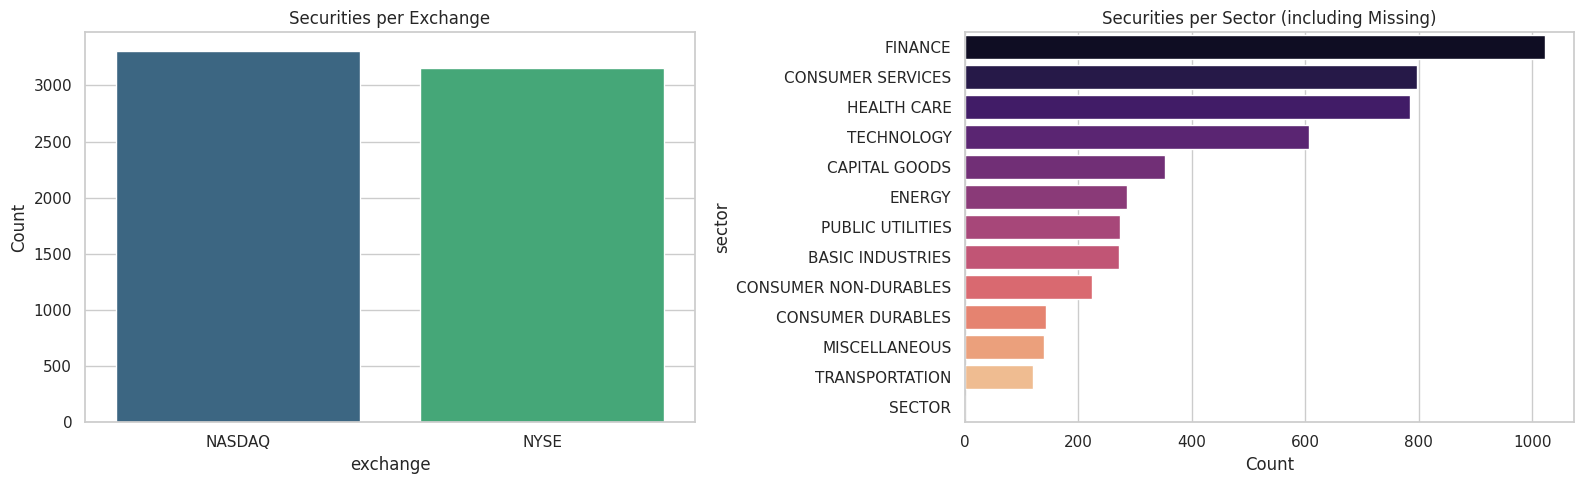

Securities per Exchange:
 exchange
NASDAQ    3308
NYSE      3152
Name: count, dtype: int64

Missing Sectors: 1440


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Stock Exchanges
exchange_counts = stocks_df['exchange'].value_counts()
sns.barplot(x=exchange_counts.index, y=exchange_counts.values, ax=axes[0], palette='viridis')
axes[0].set_title('Securities per Exchange')
axes[0].set_ylabel('Count')

# Sectors
sector_counts = stocks_df['sector'].value_counts(dropna=False)
sns.barplot(y=sector_counts.index, x=sector_counts.values, ax=axes[1], palette='magma')
axes[1].set_title('Securities per Sector (including Missing)')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

print("Securities per Exchange:\n", exchange_counts)
print("\nMissing Sectors:", stocks_df['sector'].isnull().sum())

**Explore Numerical Data:**

In [11]:
num_cols = ['open', 'high', 'low', 'close', 'volume']
desc_stats = prices_df[num_cols].describe().T
desc_stats['median'] = prices_df[num_cols].median()
display(desc_stats[['mean', 'median', 'std', 'min', '50%', 'max']])

,mean,median,std,min,50%,max
open,7.605824e+01,15.45,2.848404e+03,0.0004,15.45,2.034000e+06
high,7.803858e+01,15.66,2.996747e+03,0.0004,15.66,2.070000e+06
low,7.422060e+01,15.24,2.744816e+03,0.0001,15.24,1.440000e+06
close,7.611401e+01,15.45,2.868943e+03,0.0002,15.45,1.779750e+06
volume,1.227043e+06,126000.00,1.316686e+07,1.0000,126000.00,4.483504e+09


**Investigate Unusual Values:**

In [12]:
# Highest Close Values
top_close = prices_df.nlargest(10, 'close')

display(top_close[['ticker', 'date', 'open', 'high', 'low', 'close', 'volume']])

,ticker,date,open,high,low,close,volume
12146443,SCON,2000-02-28,1395000.000,1797750.0,1368000.00,1779750.0,400.0
12146459,SCON,2000-02-29,2034000.000,2070000.0,1440000.00,1595250.0,400.0
12146546,SCON,2000-03-13,900000.000,1404000.0,861750.00,1363500.0,300.0
17889354,CODA,2001-02-05,1354500.000,1736700.0,1354500.00,1354500.0,34.0
2444619,TVIX,2013-02-26,1375000.000,1542500.0,1300000.00,1347500.0,100.0
12146480,SCON,2000-03-02,1120500.000,1368000.0,1098280.75,1261125.0,200.0
12146437,SCON,2000-02-25,873561.625,1369125.0,873000.00,1215000.0,200.0
17107201,TOPS,2016-08-01,783000.000,1276200.0,783000.00,1189800.0,100.0
12146465,SCON,2000-03-01,1368000.000,1512000.0,1107000.00,1134000.0,300.0
12146562,SCON,2000-03-14,1352250.000,1354500.0,1080000.00,1111500.0,100.0


In [13]:
# Highest Adjusted Close Values
top_adj_close = prices_df.nlargest(10, 'adj_close')

display(top_adj_close[['ticker', 'date', 'close', 'adj_close', 'volume']])

,ticker,date,close,adj_close,volume
6174033,AAN,1987-02-27,1.296296,1.894962e+19,346900.0
6174039,AAN,1987-03-10,1.296296,1.894962e+19,20200.0
6174040,AAN,1987-03-11,1.296296,1.894962e+19,18900.0
6174041,AAN,1987-03-12,1.296296,1.894962e+19,27000.0
6174044,AAN,1987-03-17,1.296296,1.894962e+19,31000.0
6174045,AAN,1987-03-18,1.296296,1.894962e+19,272700.0
6174046,AAN,1987-03-19,1.296296,1.894962e+19,4000.0
6174049,AAN,1987-03-25,1.296296,1.894962e+19,184900.0
6174051,AAN,1987-03-27,1.287037,1.881428e+19,205200.0
6174050,AAN,1987-03-26,1.268519,1.854356e+19,20200.0


**Part 7 — Visualize the Data:**

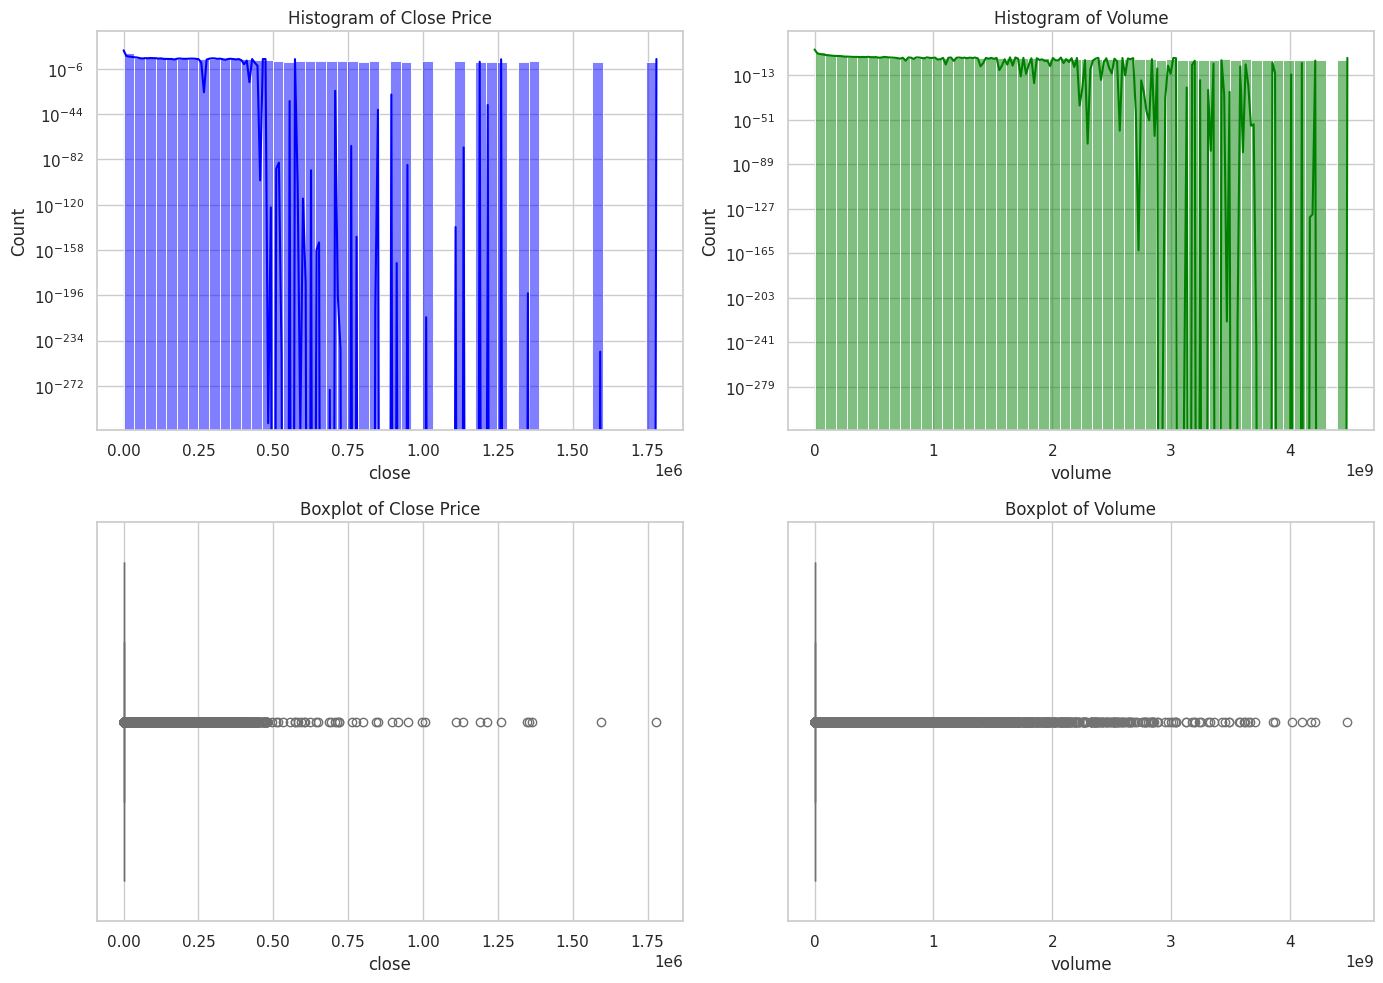

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#  Closing Price Histogram
sns.histplot(prices_df['close'], bins=50, ax=axes[0, 0], kde=True, color='blue')
axes[0, 0].set_title('Histogram of Close Price')
axes[0, 0].set_yscale('log') # Log scale helps view heavily skewed data

#  Volume Histogram
sns.histplot(prices_df['volume'], bins=50, ax=axes[0, 1], kde=True, color='green')
axes[0, 1].set_title('Histogram of Volume')
axes[0, 1].set_yscale('log')

#  Closing Price Boxplot
sns.boxplot(x=prices_df['close'], ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Boxplot of Close Price')

#  Volume Boxplot
sns.boxplot(x=prices_df['volume'], ax=axes[1, 1], color='lightgreen')
axes[1, 1].set_title('Boxplot of Volume')

plt.tight_layout()
plt.show()

**Explore One Stock: te AAPL ticker:**

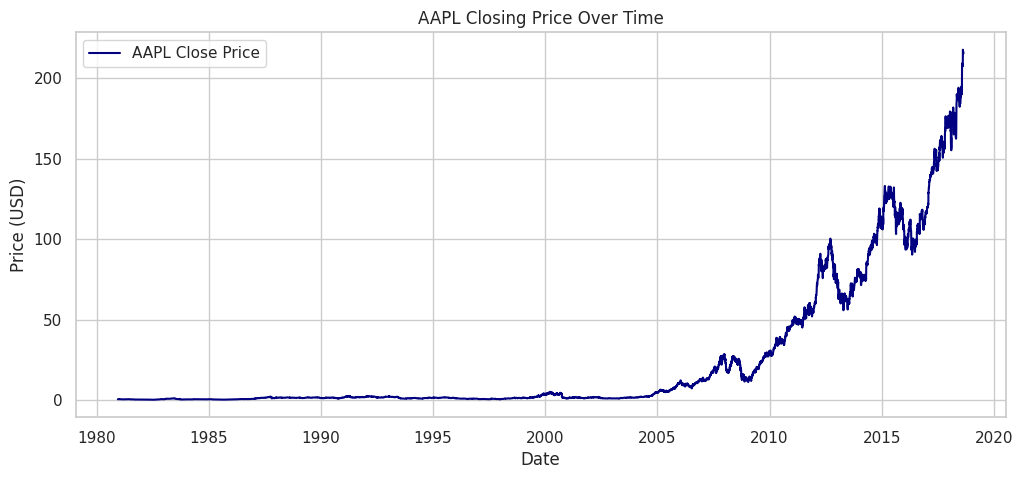

In [15]:
# Choosing the AAPL ticker
selected_ticker = 'AAPL'
stock_single = prices_df[prices_df['ticker'] == selected_ticker].sort_values('date')

plt.figure(figsize=(12, 5))
plt.plot(stock_single['date'], stock_single['close'], label=f'{selected_ticker} Close Price', color='navy')
plt.title(f'{selected_ticker} Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()